# Testing colorization model, collecting metrics, comparing 0 epoch and last (25)

### Data preparing

In [2]:
!git clone https://github.com/RailSAB/coloringModel.git

Cloning into 'coloringModel'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 19 (delta 9), reused 15 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 9.79 KiB | 3.26 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [4]:
%cd /kaggle/working/coloringModel

/kaggle/working/coloringModel


In [6]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 57.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 50.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 68.5 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.

### Imports

In [7]:
import os
from pathlib import Path
import glob
import subprocess
from tqdm import tqdm
import numpy as np
from PIL import Image
from skimage import img_as_float
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse
import pandas as pd

### Paths

In [ ]:
INPUT_DIR = '/kaggle/input/testlid'
INFERENCE_SCRIPT = 'inference.py'

# Paths to checkpoints 
WEIGHT_EPOCH_0 = '/kaggle/input/coloring/pytorch/default/1/ResUnet_epoch_0.pt'
WEIGHT_EPOCH_20 = '/kaggle/input/coloring-weights-v3-v5/pytorch/default/1/v5/ResUnet_epoch_4.pt'

# Output dirs
OUT_BASE = '/kaggle/working/results_color_compare'
OUT_E0 = os.path.join(OUT_BASE, 'epoch_0')
OUT_E20 = os.path.join(OUT_BASE, 'epoch_20')
os.makedirs(OUT_E0, exist_ok=True)
os.makedirs(OUT_E20, exist_ok=True)

IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

## Helper functions

In [9]:
def list_images(input_dir):
    files = []
    for ext in IMG_EXTS:
        files.extend(glob.glob(os.path.join(input_dir, '**', f'*{ext}'), recursive=True))
    files = sorted(files)
    return files

def run_inference(input_path, output_path, weights_path, device='cuda', use_half=True):
    cmd = [
        'python', INFERENCE_SCRIPT,
        '--input', input_path,
        '--output', output_path,
        '--weights', weights_path,
        '--device', device
    ]
    if use_half:
        cmd.append('--half')
    env = os.environ.copy()
    env['CUDA_VISIBLE_DEVICES'] = '0'
    if device == 'cuda':
        env['TORCH_FORCE_GPU_ALLOW_GROWTH'] = 'true'
    subprocess.run(cmd, check=True, env=env)

def load_rgb(path):
    img = Image.open(path).convert('RGB')
    return np.array(img)

def resize_to(src, target_shape):
    target_h, target_w = target_shape[0], target_shape[1]
    img = Image.fromarray(src)
    img = img.resize((target_w, target_h), Image.BICUBIC)
    return np.array(img)

def ssim_safe(a, b):
    h, w = a.shape[:2]
    min_dim = min(h, w)
    if min_dim < 3:
        return float('nan')
    win = min(7, min_dim if (min_dim % 2 == 1) else (min_dim - 1))
    try:
        return float(ssim(a, b, data_range=1.0, channel_axis=-1, win_size=win))
    except TypeError:
        return float(ssim(a, b, data_range=1.0, multichannel=True, win_size=win))

In [10]:
results = []
files = list_images(INPUT_DIR)
print(f'Found {len(files)} image(s) in {INPUT_DIR}')

Found 30000 image(s) in /kaggle/input/testlid


## Inference and metrics gain

In [ ]:
for img_path in tqdm(files, desc='Images'):
    fname = os.path.basename(img_path)
    out0 = os.path.join(OUT_E0, fname.replace('.', '_ft.'))
    out20 = os.path.join(OUT_E20, fname.replace('.', '_ft.'))
    for epoch, weights, out_dir, out_path in [
        (0, WEIGHT_EPOCH_0, OUT_E0, out0),
        (20, WEIGHT_EPOCH_20, OUT_E20, out20),
    ]:
        try:
            if not os.path.exists(out_path):
                run_inference(img_path, out_path, weights)
            else:
                pass
        except subprocess.CalledProcessError as e:
            print(f'Inference failed for {fname} epoch {epoch}:', e)
            results.append({'file': fname, 'epoch': epoch, 'error': str(e)})
            continue
            
    if os.path.exists(out0) and os.path.exists(out20):
        try:
            gt = load_rgb(img_path)
            pred0 = load_rgb(out0)
            pred20 = load_rgb(out20)
            # Ensure same size
            if pred0.shape[:2] != gt.shape[:2]:
                pred0 = resize_to(pred0, gt.shape)
            if pred20.shape[:2] != gt.shape[:2]:
                pred20 = resize_to(pred20, gt.shape)
            # Convert to float in [0,1]
            gt_f = img_as_float(gt)
            p0_f = img_as_float(pred0)
            p20_f = img_as_float(pred20)
            # Compute metrics (multichannel for ssim)
            mse0 = float(mse(gt_f, p0_f))
            psnr0 = float(psnr(gt_f, p0_f, data_range=1.0))
            ssim0 = ssim_safe(gt_f, p0_f)
            mse20 = float(mse(gt_f, p20_f))
            psnr20 = float(psnr(gt_f, p20_f, data_range=1.0))
            ssim20 = ssim_safe(gt_f, p20_f)
            results.append({'file': fname, 'epoch': 0, 'mse': mse0, 'psnr': psnr0, 'ssim': ssim0, 'out_path': out0})
            results.append({'file': fname, 'epoch': 20, 'mse': mse20, 'psnr': psnr20, 'ssim': ssim20, 'out_path': out20})
        except Exception as e:
            print(f'Metric computation failed for {fname}:', e)
            results.append({'file': fname, 'epoch': 'metric_error', 'error': str(e)})
    else:
        print(f'Outputs missing for {fname}: e0 exists? {os.path.exists(out0)}, e20 exists? {os.path.exists(out20)}')


## One sample example

Device: cuda
Sample: city_093405.jpg
First param device: cuda:0
First param device: cuda:0


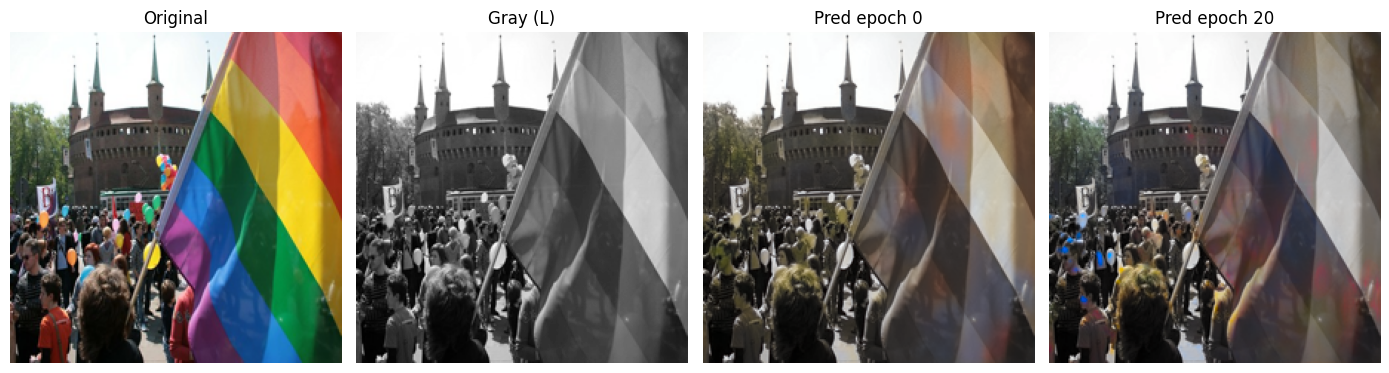

In [ ]:
repo_root = '/kaggle/working/coloringModel'
if repo_root not in sys.path:
    sys.path.append(repo_root)
from models import build_models
from utils import lab_to_rgb

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

all_imgs = []
for ext in ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'):
    all_imgs += glob.glob(os.path.join(INPUT_DIR, f'**/*{ext}'), recursive=True)
assert all_imgs, f'No images found in {INPUT_DIR}'
img_path = random.choice(all_imgs)
print('Sample:', os.path.basename(img_path))

img_rgb = Image.open(img_path).convert('RGB')
img_rgb_disp = img_rgb.resize((224, 224))
img_L = img_rgb.convert('L').resize((224, 224))
arr = np.array(img_L).astype('float32') / 255.0
arr = arr.reshape((224, 224, 1))
to_tensor = transforms.ToTensor()
L = to_tensor(arr).unsqueeze(0).to(device).float() 

def load_gen(wp):
    assert os.path.isfile(wp), f'Missing weights: {wp}'
    gen, _ = build_models(device=device, gen_weights=wp)
    gen = gen.to(device).eval()
    print('First param device:', next(gen.parameters()).device)
    return gen

gen0 = load_gen(WEIGHT_EPOCH_0)
gen20 = load_gen(WEIGHT_EPOCH_20)

with torch.no_grad():
    pred_ab_0 = gen0(L)
    pred_ab_20 = gen20(L)
    if device.type == 'cuda':
        torch.cuda.synchronize()

rgb0 = lab_to_rgb(L, pred_ab_0)
rgb20 = lab_to_rgb(L, pred_ab_20)
rgb0_u8 = (rgb0[0] * 255).astype(np.uint8)
rgb20_u8 = (rgb20[0] * 255).astype(np.uint8)

# Show: original / gray / epoch0 / epoch20
fig, axs = plt.subplots(1, 4, figsize=(14, 4))
axs[0].imshow(img_rgb_disp); axs[0].set_title('Original'); axs[0].axis('off')
axs[1].imshow(img_L, cmap='gray'); axs[1].set_title('Gray (L)'); axs[1].axis('off')
axs[2].imshow(rgb0_u8); axs[2].set_title('Pred epoch 0'); axs[2].axis('off')
axs[3].imshow(rgb20_u8); axs[3].set_title('Pred epoch 20'); axs[3].axis('off')
plt.tight_layout(); plt.show()